# 01 — Классические базовые решения

Этот ноутбук строит **классические референсы** для задачи Марковица на двух универсах (S&P 500 и MOEX) и сравнивает три классических подхода:

1. **Continuous MVO** через CVXPY (без cardinality)
2. **Brute force** на малом подмножестве для проверки правильности
3. **MIQP** через SCIP и ECOS_BB с cardinality

Результаты этого ноутбука используются как baseline для последующих экспериментов A (scalability) и B (quality at fixed budget).

**Ожидаемое время выполнения:** ~1-2 минуты.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cif.problem import PortfolioProblem
from cif.data.statistics import log_returns, annualised_mu, annualised_sigma
from cif.classical.continuous import solve_continuous_mvo, efficient_frontier
from cif.classical.brute_force import brute_force_discrete, brute_force_cardinality_continuous
from cif.classical.milp import solve_miqp_scip, solve_miqp_ecos_bb

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

## Загрузка данных

Используем заранее скачанные через `python -m cif.scripts.download_data --universe both` parquet-файлы. На HPC ноутбук читает те же файлы, перенесённые через scp.

In [2]:
def load_universe(key, train_start='2015-01-01', train_end='2024-12-31'):
    prices = pd.read_parquet(f'../data/processed/{key}_prices.parquet')
    train = prices.loc[train_start:train_end]
    rets = log_returns(train)
    mu = annualised_mu(rets).values
    sigma = annualised_sigma(rets, method='ledoit_wolf').values
    return train, rets, mu, sigma, tuple(rets.columns)

sp_prices, sp_rets, sp_mu, sp_sigma, sp_names = load_universe('sp500')
moex_prices, moex_rets, moex_mu, moex_sigma, moex_names = load_universe('moex')

print(f'S&P 500: {len(sp_names)} tickers, {len(sp_rets)} days, training window {sp_rets.index[0].date()} … {sp_rets.index[-1].date()}')
print(f'MOEX:    {len(moex_names)} tickers, {len(moex_rets)} days, training window {moex_rets.index[0].date()} … {moex_rets.index[-1].date()}')
print(f'\nS&P mu range:    [{sp_mu.min():.3f}, {sp_mu.max():.3f}]   (annualised log returns)')
print(f'MOEX mu range:   [{moex_mu.min():.3f}, {moex_mu.max():.3f}]')
print(f'S&P sigma diag range:  [{sp_sigma.diagonal().min():.4f}, {sp_sigma.diagonal().max():.4f}]')
print(f'MOEX sigma diag range: [{moex_sigma.diagonal().min():.4f}, {moex_sigma.diagonal().max():.4f}]')

S&P 500: 90 tickers, 2515 days, training window 2015-01-05 … 2024-12-31
MOEX:    28 tickers, 2503 days, training window 2015-01-21 … 2024-12-30

S&P mu range:    [-0.081, 0.382]   (annualised log returns)
MOEX mu range:   [-0.470, 0.721]
S&P sigma diag range:  [0.0384, 0.3611]
MOEX sigma diag range: [0.5201, 0.5201]


## Continuous MVO: efficient frontier

Запускаем `solve_continuous_mvo` для нескольких значений risk aversion λ — получаем непрерывную efficient frontier как baseline.

In [3]:
def trace_frontier(mu, sigma, names, n_points=20, lam_range=(0.5, 50.0)):
    p = PortfolioProblem(mu=mu, sigma=sigma, asset_names=names)
    lams = np.logspace(np.log10(lam_range[0]), np.log10(lam_range[1]), n_points)
    sols = efficient_frontier(p, lams)
    rows = []
    for lam, sol in zip(lams, sols):
        ret = float(mu @ sol.weights)
        var = float(sol.weights @ sigma @ sol.weights)
        rows.append({'lambda': lam, 'return': ret, 'std': np.sqrt(var),
                     'sharpe': ret / np.sqrt(var) if var > 0 else 0,
                     'n_nonzero': int((sol.weights > 1e-4).sum()),
                     'time_ms': sol.wall_time_s * 1000})
    return pd.DataFrame(rows), sols

sp_frontier, sp_sols = trace_frontier(sp_mu, sp_sigma, sp_names)
moex_frontier, moex_sols = trace_frontier(moex_mu, moex_sigma, moex_names)

print('S&P 500:'); display(sp_frontier.head())
print('MOEX:'); display(moex_frontier.head())

S&P 500:


,lambda,return,std,sharpe,n_nonzero,time_ms
0,0.500000,0.359761,0.392933,0.915578,2,18.446828
1,0.637137,0.355183,0.371852,0.955173,3,15.897643
2,0.811888,0.351065,0.356003,0.986130,3,24.011501
3,1.034569,0.347022,0.343402,1.010541,4,15.942134
4,1.318325,0.343506,0.334455,1.027061,4,15.707040


MOEX:


,lambda,return,std,sharpe,n_nonzero,time_ms
0,0.500000,0.721005,0.721149,0.999800,1,4.673667
1,0.637137,0.721005,0.721149,0.999800,1,4.768659
2,0.811888,0.721005,0.721149,0.999800,1,4.525160
3,1.034569,0.675685,0.651443,1.037213,3,4.491896
4,1.318325,0.619087,0.571733,1.082827,4,4.624609


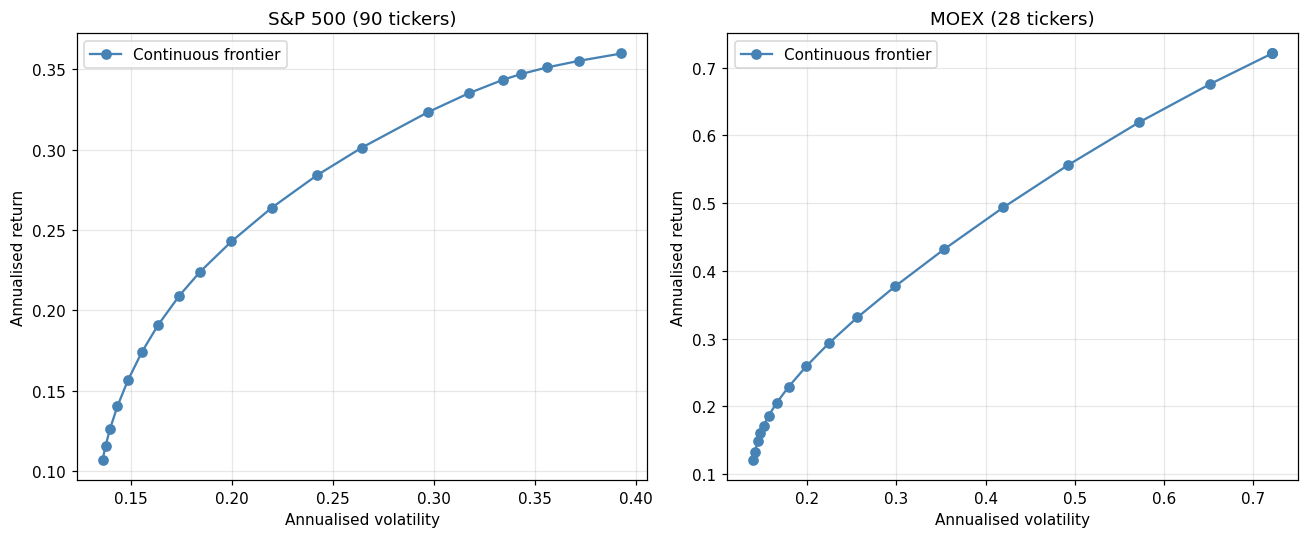

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (df, label) in zip(axes, [(sp_frontier, 'S&P 500 (90 tickers)'), (moex_frontier, 'MOEX (28 tickers)')]):
    ax.plot(df['std'], df['return'], 'o-', color='steelblue', label='Continuous frontier')
    ax.set_xlabel('Annualised volatility')
    ax.set_ylabel('Annualised return')
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## Continuous MVO with cardinality (через MIQP)

Сравниваем continuous MVO без cardinality и MIQP с разными K — показывает, как cardinality сужает достижимое множество и насколько "теряем" в efficient frontier.

In [5]:
def cardinality_frontier(mu, sigma, names, K_values, lam=2.0):
    rows = []
    for K in K_values:
        p = PortfolioProblem(mu=mu, sigma=sigma, asset_names=names, risk_aversion=lam, cardinality=K)
        t0 = time.perf_counter()
        sol = solve_miqp_scip(p, time_limit_s=120.0)
        t = time.perf_counter() - t0
        ret = float(mu @ sol.weights)
        var = float(sol.weights @ sigma @ sol.weights)
        rows.append({
            'K': K, 'objective': sol.objective, 'return': ret, 'std': np.sqrt(var),
            'sharpe': ret/np.sqrt(var) if var > 0 else 0,
            'n_nonzero': sol.solver_meta['n_nonzero'], 'time_s': t, 'feasible': sol.feasible,
        })
    return pd.DataFrame(rows)

sp_card = cardinality_frontier(sp_mu, sp_sigma, sp_names, K_values=[5, 10, 15, 20, 30, 50, 90])
moex_card = cardinality_frontier(moex_mu, moex_sigma, moex_names, K_values=[3, 5, 8, 12, 20, 28])

print('S&P 500 cardinality sweep (SCIP MIQP, lambda=2):'); display(sp_card)
print('\nMOEX cardinality sweep:'); display(moex_card)

S&P 500 cardinality sweep (SCIP MIQP, lambda=2):


,K,objective,return,std,sharpe,n_nonzero,time_s,feasible
0,5,-0.234926,0.328824,0.306427,1.073088,5,1.723265,True
1,10,-0.235137,0.326764,0.302699,1.079502,6,0.792940,True
2,15,-0.235137,0.326764,0.302699,1.079502,6,0.740867,True
3,20,-0.235137,0.326764,0.302699,1.079502,6,0.772131,True
4,30,-0.235137,0.326764,0.302699,1.079502,6,0.711904,True
5,50,-0.235137,0.326764,0.302699,1.079502,6,0.732206,True
6,90,-0.235138,0.326819,0.302789,1.079361,6,0.490802,True



MOEX cardinality sweep:


,K,objective,return,std,sharpe,n_nonzero,time_s,feasible
0,3,-0.309800,0.550377,0.490487,1.122104,3,0.105854,True
1,5,-0.316534,0.521355,0.452571,1.151985,5,0.085898,True
2,8,-0.317924,0.510779,0.439152,1.163102,8,0.077591,True
3,12,-0.317924,0.510779,0.439152,1.163102,8,0.064361,True
4,20,-0.317924,0.510779,0.439152,1.163102,8,0.066765,True
5,28,-0.317924,0.510779,0.439152,1.163102,8,0.073650,True


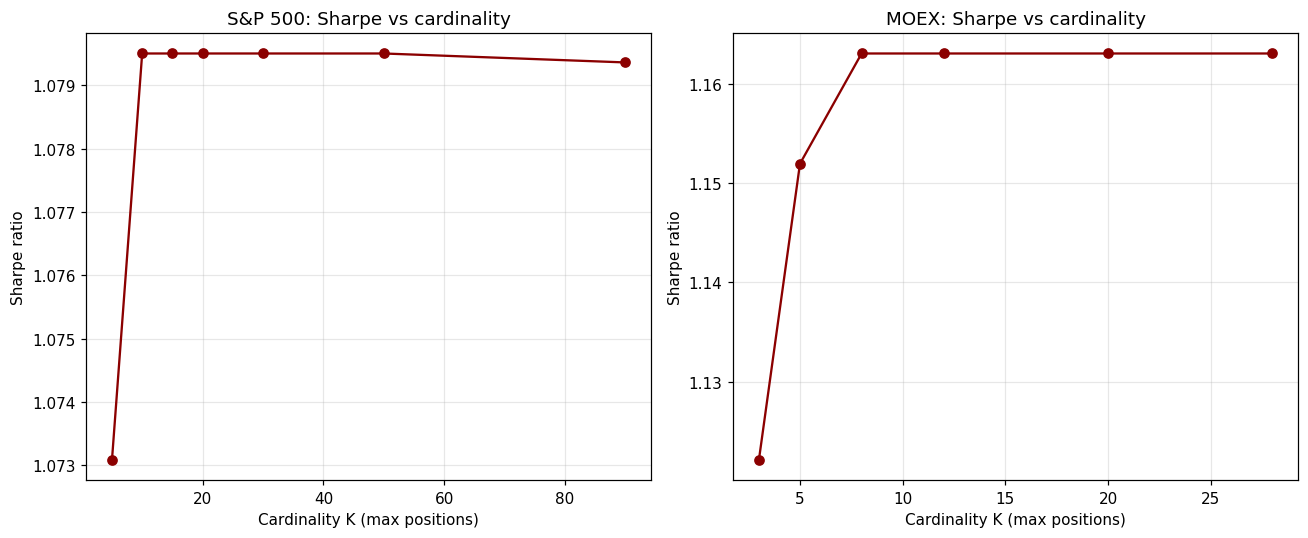

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, label in zip(axes, [sp_card, moex_card], ['S&P 500', 'MOEX']):
    ax.plot(df['K'], df['sharpe'], 'o-', color='darkred')
    ax.set_xlabel('Cardinality K (max positions)')
    ax.set_ylabel('Sharpe ratio')
    ax.set_title(f'{label}: Sharpe vs cardinality')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

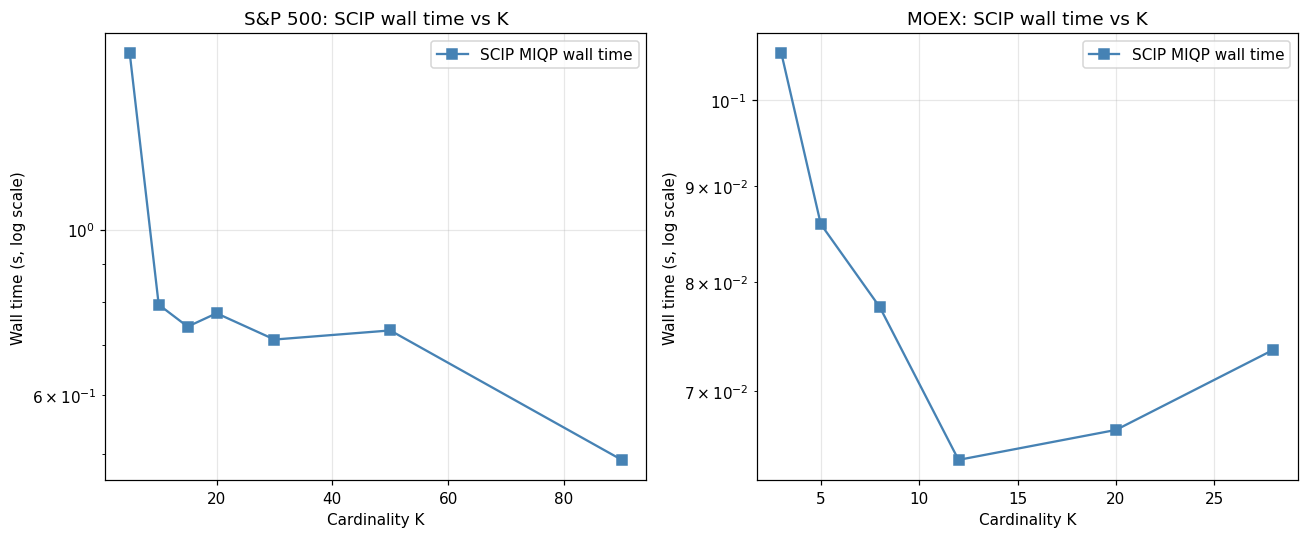

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, label in zip(axes, [sp_card, moex_card], ['S&P 500', 'MOEX']):
    ax.semilogy(df['K'], df['time_s'], 's-', color='steelblue', label='SCIP MIQP wall time')
    ax.set_xlabel('Cardinality K')
    ax.set_ylabel('Wall time (s, log scale)')
    ax.set_title(f'{label}: SCIP wall time vs K')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## Sanity check: brute force vs SCIP на малом N

Для малых задач (N ≤ 12) brute-force даёт **сертифицированный** оптимум. Сравнение с SCIP подтверждает корректность MIQP формулировки.

In [8]:
def sanity_check(mu_full, sigma_full, names, n_use, K, n_levels=10):
    mu = mu_full[:n_use]; sigma = sigma_full[:n_use, :n_use]
    sub_names = names[:n_use]
    p = PortfolioProblem(mu=mu, sigma=sigma, asset_names=sub_names, risk_aversion=2.0, cardinality=K)

    bf = brute_force_cardinality_continuous(p, cardinality=K)
    scip = solve_miqp_scip(p)
    ecos = solve_miqp_ecos_bb(p)

    print(f'N={n_use}, K={K}:')
    print(f'  brute force:   obj={bf.objective:.6f}  ({bf.solver_meta["subsets_evaluated"]} subsets, {bf.wall_time_s*1000:.0f}ms)')
    print(f'  SCIP MIQP:     obj={scip.objective:.6f}  ({scip.wall_time_s*1000:.0f}ms)')
    print(f'  ECOS_BB MIQP:  obj={ecos.objective:.6f}  ({ecos.wall_time_s*1000:.0f}ms)')
    print()
    return bf, scip, ecos

for N, K in [(8, 3), (10, 4), (12, 5)]:
    sanity_check(sp_mu, sp_sigma, sp_names, N, K)

N=8, K=3:
  brute force:   obj=-0.153793  (56 subsets, 315ms)
  SCIP MIQP:     obj=-0.153793  (356ms)
  ECOS_BB MIQP:  obj=-0.153793  (8ms)



N=10, K=4:
  brute force:   obj=-0.154359  (210 subsets, 1154ms)
  SCIP MIQP:     obj=-0.154359  (128ms)
  ECOS_BB MIQP:  obj=-0.154359  (10ms)



N=12, K=5:
  brute force:   obj=-0.154359  (792 subsets, 4395ms)
  SCIP MIQP:     obj=-0.154359  (58ms)
  ECOS_BB MIQP:  obj=-0.154359  (12ms)



## Сводка: что мы получили

1. **Continuous MVO** (CVXPY) даёт **верхнюю границу** efficient frontier — всё последующее (дискретные методы, cardinality) лежит ниже.
2. **MIQP с cardinality** (SCIP) — это **главный classical baseline**, против которого мы будем сравнивать quantum-inspired методы в Experiment A. Время растёт быстро с K и N: уже на N=90, K=20 это секунды-десятки секунд.
3. **ECOS_BB** — встроенный bundled MIP solver cvxpy. Быстрый на малых задачах, начинает уступать на больших.
4. **Brute force** для N ≤ 12 даёт сертифицированный оптимум, и SCIP/ECOS_BB сходятся к нему — формулировка корректна.
5. **Sharpe vs K**: видно, что увеличение K улучшает Sharpe только до определённого порога — после ~20-30 активов на S&P 500 marginal improvement становится маленьким, что физически оправдывает использование cardinality constraints в реальных фондах.

**Следующий шаг:** ноутбук `02_quantum_inspired_neal.ipynb` запускает quantum-inspired SA (`neal`) на тех же данных и сравнивает scalability.